100%|██████████| 805/805 [00:06<00:00, 129.22it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...


100%|██████████| 805/805 [00:05<00:00, 158.32it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...
[TRAIN] epoch:  0 batch:  0 step:  50 loss:  0.6089905500411987 recon_detail loss:  tensor(0.8064, device='mps:0') kl loss:  tensor(20.3253, device='mps:0')


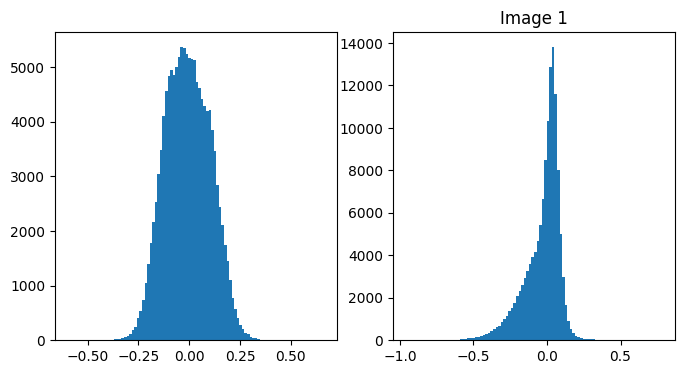

vmin -0.18530189 vmax -0.18367791


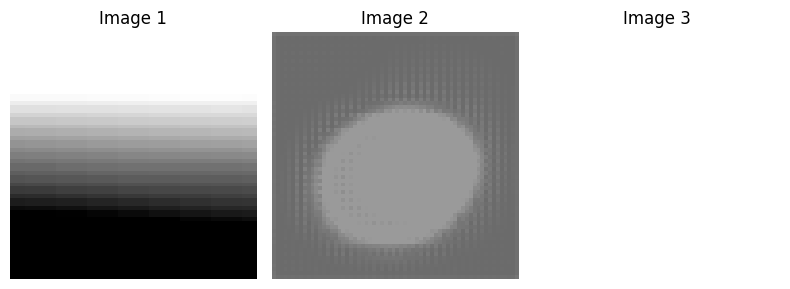

[TRAIN] epoch:  0 batch:  1 step:  100 loss:  0.41835904121398926 recon_detail loss:  tensor(0.8004, device='mps:0') kl loss:  tensor(1.7707, device='mps:0')


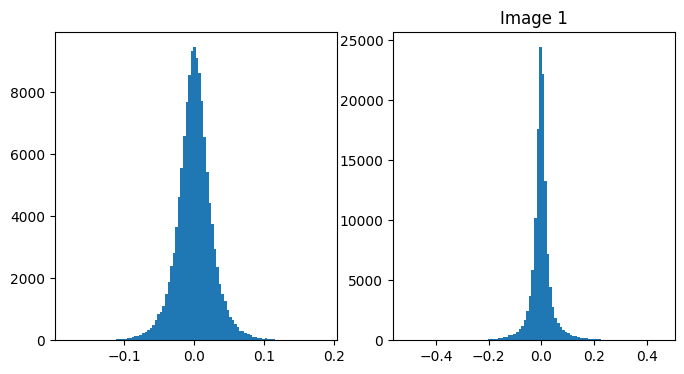

vmin -0.18477045 vmax -0.1844689


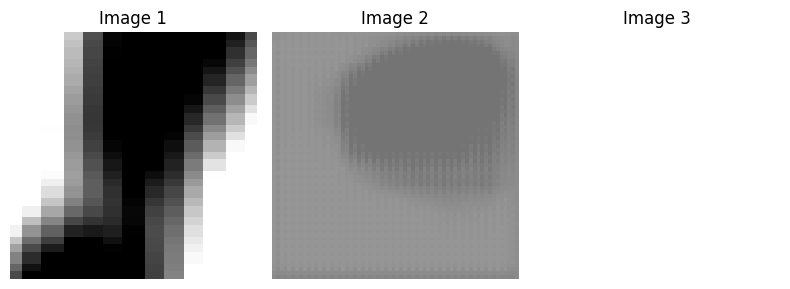

[TRAIN] epoch:  0 batch:  2 step:  150 loss:  0.35700803995132446 recon_detail loss:  tensor(0.5859, device='mps:0') kl loss:  tensor(6.2675, device='mps:0')


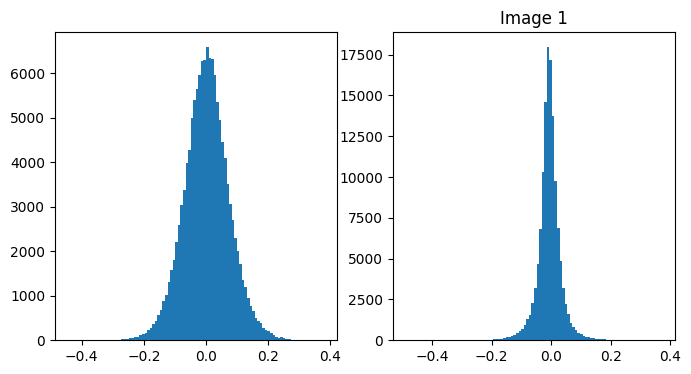

vmin -0.18475437 vmax -0.18446064


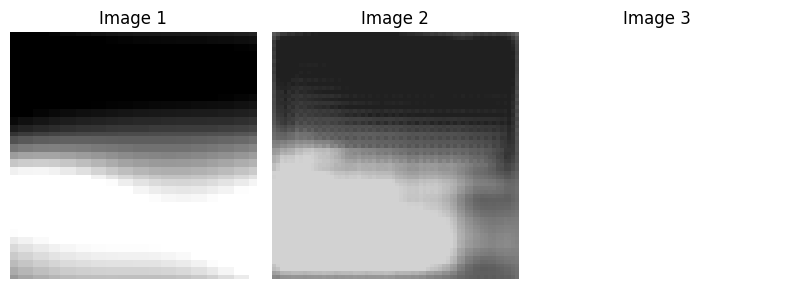

[TRAIN] epoch:  0 batch:  3 step:  200 loss:  0.3044302761554718 recon_detail loss:  tensor(0.4395, device='mps:0') kl loss:  tensor(8.4044, device='mps:0')


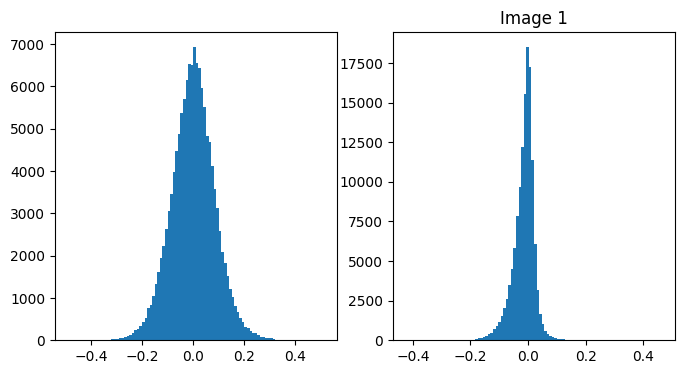

vmin -0.18467878 vmax -0.18439522


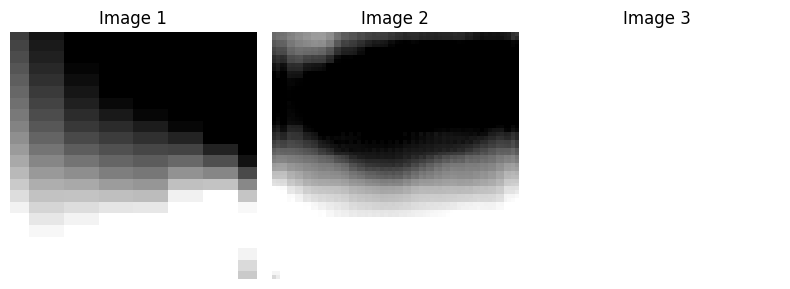

[TRAIN] epoch:  0 batch:  3 step:  250 loss:  0.2896876931190491 recon_detail loss:  tensor(0.4376, device='mps:0') kl loss:  tensor(7.0347, device='mps:0')


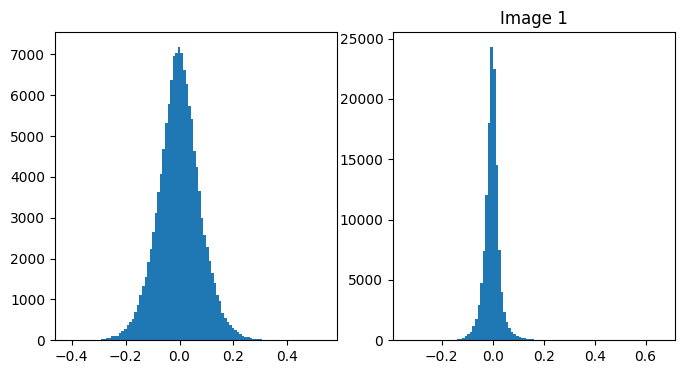

vmin -0.18469983 vmax -0.18433121


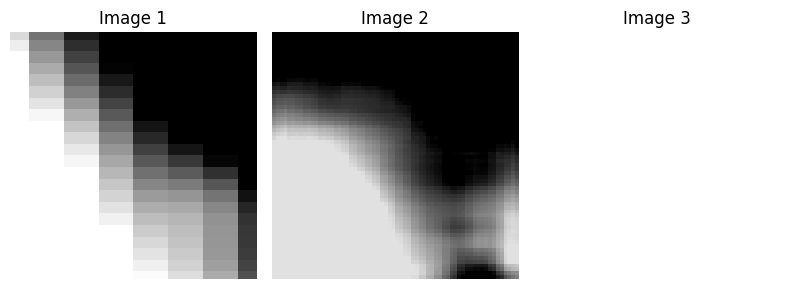

[TRAIN] epoch:  0 batch:  4 step:  300 loss:  0.2894343137741089 recon_detail loss:  tensor(0.4283, device='mps:0') kl loss:  tensor(7.4964, device='mps:0')


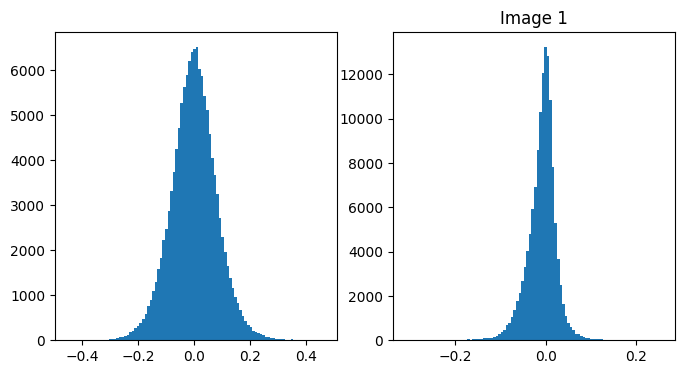

vmin -0.19129404 vmax -0.17899618


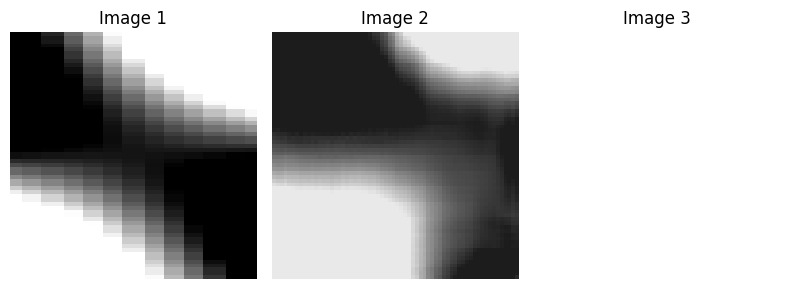

[TRAIN] epoch:  0 batch:  5 step:  350 loss:  0.2930392920970917 recon_detail loss:  tensor(0.4641, device='mps:0') kl loss:  tensor(6.0707, device='mps:0')


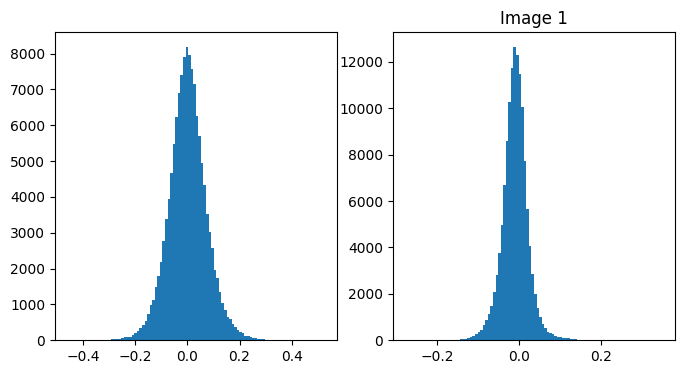

vmin -0.18465523 vmax -0.18454541


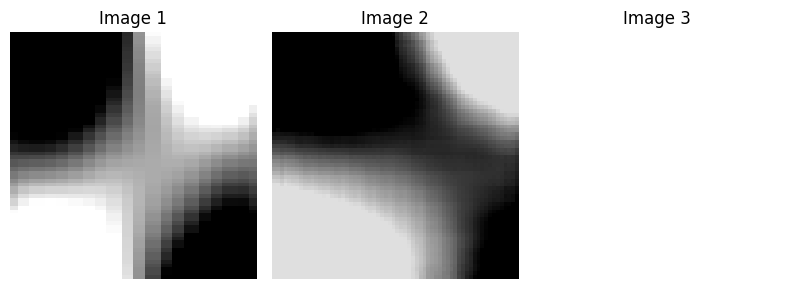

[TRAIN] epoch:  0 batch:  6 step:  400 loss:  0.3062870502471924 recon_detail loss:  tensor(0.4909, device='mps:0') kl loss:  tensor(5.9600, device='mps:0')


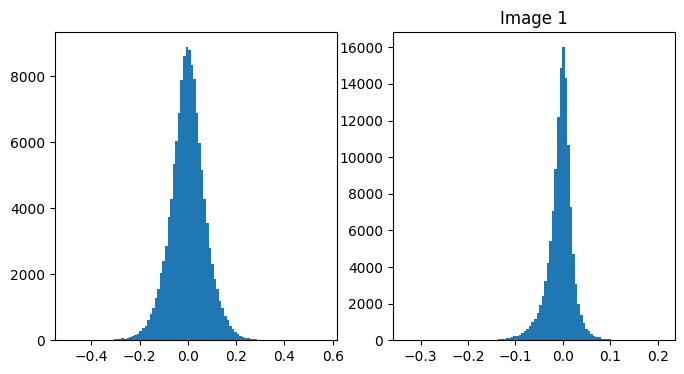

vmin -0.18460909 vmax -0.18460223


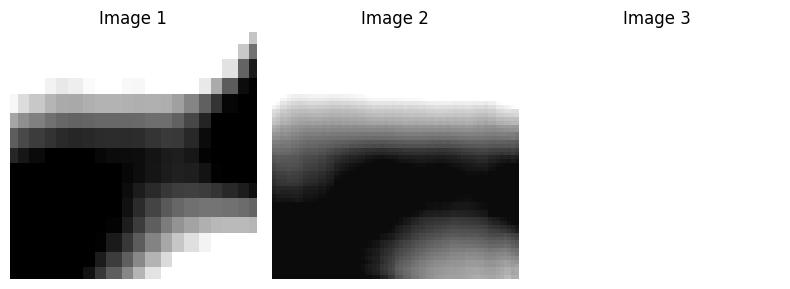

[TRAIN] epoch:  0 batch:  7 step:  450 loss:  0.31039124727249146 recon_detail loss:  tensor(0.4852, device='mps:0') kl loss:  tensor(6.6987, device='mps:0')


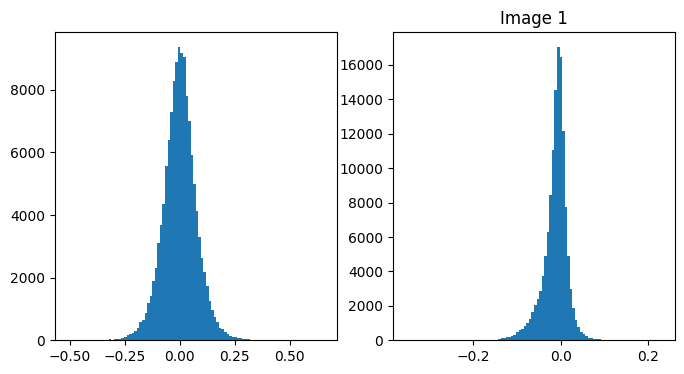

vmin -0.20815997 vmax -0.16016038


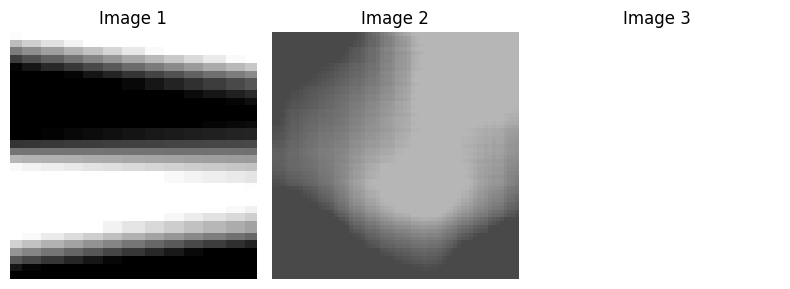

[TRAIN] epoch:  0 batch:  7 step:  500 loss:  0.29186856746673584 recon_detail loss:  tensor(0.4436, device='mps:0') kl loss:  tensor(6.8981, device='mps:0')


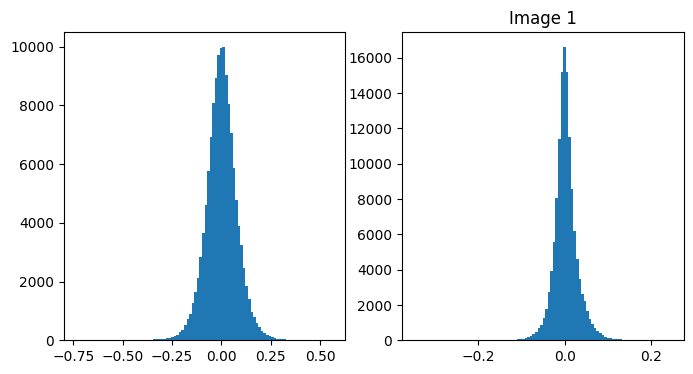

vmin -0.20782161 vmax -0.16074708


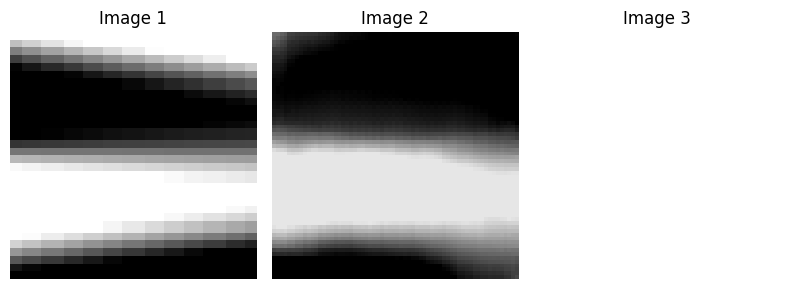

[TRAIN] epoch:  0 batch:  8 step:  550 loss:  0.28970178961753845 recon_detail loss:  tensor(0.4442, device='mps:0') kl loss:  tensor(6.6245, device='mps:0')


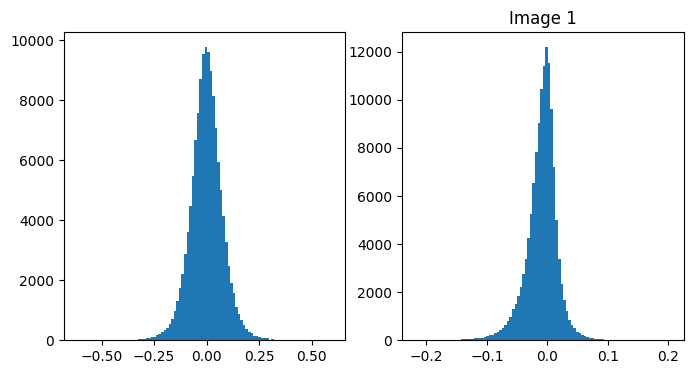

vmin -0.1849128 vmax -0.18429242


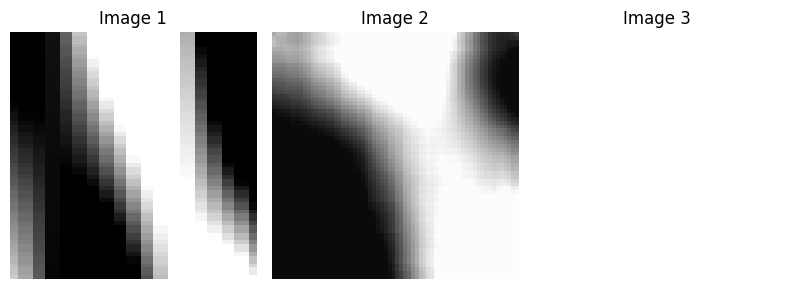

[TRAIN] epoch:  0 batch:  9 step:  600 loss:  0.2709360122680664 recon_detail loss:  tensor(0.4029, device='mps:0') kl loss:  tensor(6.8788, device='mps:0')


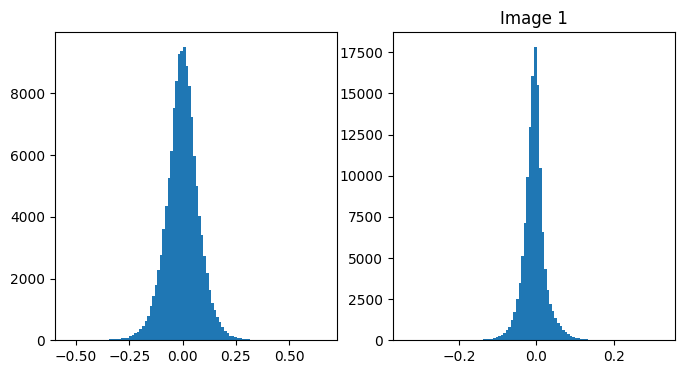

vmin -0.18939233 vmax -0.17993733


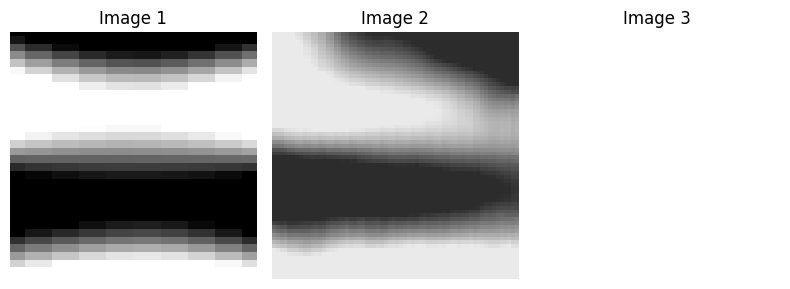

In [ ]:
import torch
import torch.nn.functional as F
from fem_dataset_to_image_full_mesh_diffusion import FemImageDataset as MeshDataset
from fem_model import ScalingVAE3
import json
from torch.utils.data import DataLoader
from utils import EarlyStopping
import gc
import numpy as np
import matplotlib.pyplot as plt


early_stopping = EarlyStopping(
    patience=50,     # FEM/GNN은 15~30 권장
    min_delta=1e-6,  # loss 스케일에 맞게
    mode="min"
)
def collate_flatten(batch): 
    images, conds = [], [] 
    batch_size=len(batch) 
    step_num_in_batch=len(batch[0]["image"]) 
    idxs=[] 
    for i in range(batch_size): 
        idx = torch.randperm(len(batch[0]["image"])) 
        idxs.append(idx) 
        # print(batch[i]['min_max'])
    idxs=np.array(idxs).T 

    for i in range(step_num_in_batch): 
        batch_images=[] 
        batch_conds=[] 
        for b_i,b in enumerate(batch): 
            id=idxs[i][b_i] 
            batch_images.append(b['image'][id]) 
            batch_conds.append(b['cond'][id]) 
        images.append(batch_images) 
        conds.append(batch_conds) 
    return { "image": images, "cond": conds, }

def draw(data1,data2,model_param): 
    stride=1 
    clip_q=(0.25,0.75) 
    cmap="jet" 
    ql, qh = np.quantile(data1.cpu().detach().numpy(), clip_q) 
    Uf1_clip = np.clip(data1.cpu().detach().numpy(), ql, qh) 
    ql, qh = np.quantile(data2.cpu().detach().numpy(), clip_q) 
    Uf2_clip = np.clip(data2.cpu().detach().numpy(), ql, qh) 
    print('vmin',Uf1_clip.min(),'vmax',Uf1_clip.max())
    plt.figure(figsize=(8, 4)) 
    plt.subplot(1, 3, 1) 
    plt.imshow(Uf1_clip, cmap="gray",vmin=Uf1_clip.min(),vmax=Uf1_clip.max()) 
    plt.title("Image 1") 
    plt.axis("off") 
    plt.subplot(1, 3, 2) 
    plt.imshow(Uf2_clip, cmap="gray",vmin=Uf1_clip.min(),vmax=Uf1_clip.max())
    plt.title("Image 2") 
    plt.axis("off") 
    plt.subplot(1, 3, 3) 
    plt.imshow(np.abs(Uf1_clip-Uf2_clip), cmap="gray",vmin=Uf1_clip.min(),vmax=Uf1_clip.max())
    plt.title("Image 3") 
    plt.axis("off")
    plt.tight_layout() 
    plt.show()

def kl_divergence_gaussian(mu, logvar, clamp=(-10, 10)):
    """
    KL( N(mu, var) || N(0, I) )
    Supports mu/logvar with shape:
      [B, Z] or [B, C, H, W] or [B, ...]
    """
    if clamp is not None:
        logvar = torch.clamp(logvar, min=clamp[0], max=clamp[1])

    # flatten all non-batch dimensions
    mu = mu.view(mu.size(0), -1)
    logvar = logvar.view(logvar.size(0), -1)

    kl = 0.5 * torch.sum(
        torch.exp(logvar) + mu**2 - 1.0 - logvar,
        dim=1
    )

    return kl.mean()

def charbonnier_loss(pred: torch.Tensor,
                     target: torch.Tensor,
                     eps: float = 1e-8,
                     reduction: str = "mean") -> torch.Tensor:
    """
    Charbonnier loss (a smooth L1 / pseudo-Huber variant):
        L = sqrt((pred - target)^2 + eps^2)

    Args:
        pred, target: same shape tensors
        eps: smoothing term (bigger -> more L1-like near 0)
        reduction: "mean" | "sum" | "none"

    Returns:
        loss tensor (scalar if reduced)
    """
    if pred.shape != target.shape:
        raise ValueError(f"Shape mismatch: pred{pred.shape} vs target{target.shape}")

    diff = pred - target
    loss = torch.sqrt(diff * diff + eps * eps)

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    if reduction == "none":
        return loss
    raise ValueError("reduction must be one of {'mean','sum','none'}")

def cvae_loss(x, scaled_x_hat, x_hat, mu, logvar, beta=1e-3):
    mean = x.mean(dim=(1,2,3), keepdim=True) 
    std = x.std(dim=(1,2,3), keepdim=True) + 1e-6 
    x_norm=(x-mean)/std 
    recon = charbonnier_loss(x, x_hat) 
    recon_detail = charbonnier_loss(x_norm,scaled_x_hat)
    kl = kl_divergence_gaussian(mu, logvar) 
    scale=recon.mean().item()/recon_detail.mean().item() 
    return 0.4*recon + 0.5*recon_detail + beta * kl, {"recon": recon.detach(),"recon_detail":recon_detail.detach(), "kl": kl.detach()}
def draw_latent(mu, logvar, clamp=(-10, 10)): 
    if clamp is not None: 
        logvar = torch.clamp(logvar, min=clamp[0], max=clamp[1]) 
        mu = mu.view(mu.size(0), -1) 
        logvar = logvar.view(logvar.size(0), -1) 
        plt.figure(figsize=(8, 4)) 
        plt.subplot(1, 2, 1) 
        plt.hist(mu.flatten().detach().cpu(), bins=100) 
        plt.subplot(1, 2, 2) 
        plt.hist(logvar.flatten().detach().cpu(), bins=100) 
        plt.title("Image 1") 
        plt.show()
def train_one_epoch(model, loader, device, opt, model_param,epoch): 
    model.train() 
    total = 0.0 
    count=0 
    beta_target=1e-1
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            scaled_x_hat,x_hat, mu, logvar, _ = model(s_batch['image']) 
            loss, parts = cvae_loss(s_batch['image'], scaled_x_hat,x_hat, mu, logvar, beta=beta) 
            opt.zero_grad() 
            loss.backward() 
            opt.step() 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[TRAIN] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts['recon_detail'] ,'kl loss: ', parts['kl']) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                pred_image=x_hat[0,:][(model_param['in_channels']-1)//2].cpu()
                draw_latent(mu, logvar, clamp=(-10, 10))
                draw(origin_image,pred_image,model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)
@torch.no_grad()
def eval_one_epoch(model, loader, device,  model_param,epoch):
    model.eval()
    total = 0.0 
    count=0 
    beta_target=1e-1
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            scaled_x_hat,x_hat, mu, logvar, _ = model(s_batch['image']) 
            loss, parts = cvae_loss(s_batch['image'], scaled_x_hat,x_hat, mu, logvar, beta=beta) 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[VALID] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'kl loss: ', parts['kl']) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                pred_image=x_hat[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,pred_image,model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)

def main():
    root = "./data"
    if torch.cuda.is_available() :
        device='cuda'
    elif torch.backends.mps.is_available() :
        device='mps'
    else :
        device='cpu'

    model_param={ 'in_channels':3, 
                'out_channels':3,
                'GRID':64,
                'loss_scale':1.0,
                'learning_rate':1e-3,
                'num_epochs':1000,
                'base':256,
                'latent_dim':128,
                'batch_size':64,
                'depth':4 } 
    
    train_ds = MeshDataset(root_dir=root,type='train',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 
    val_ds= MeshDataset(root_dir=root,type='valid',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 

    train_loader = DataLoader(train_ds, batch_size=model_param['batch_size'], shuffle=True, collate_fn=collate_flatten) 
    val_loader = DataLoader(val_ds, batch_size=model_param['batch_size'], shuffle=False, collate_fn=collate_flatten) 
    example = train_ds[0] 
    model_param['cond_dim']=len(example['cond'][0]) 
    model_param['dataset_scale_info']=train_ds.scale_info 

    model = ScalingVAE3( in_channels=model_param['in_channels'], 
                latent_dim=model_param['latent_dim'], 
                base=model_param['base'],
                depth=model_param['depth'] ).to(device)


    optimizer = torch.optim.Adam(model.parameters(), lr=model_param['learning_rate'], weight_decay=1e-6)
    loss_dict={}
    for epoch in range(model_param['num_epochs']):        
        train_loss = train_one_epoch(model, train_loader, device, optimizer,model_param,epoch)
        val_loss = eval_one_epoch(model, val_loader, device,model_param,epoch)
        loss_dict[epoch] = {'train_loss':train_loss, 'val_loss':val_loss}   
        print(f"Epoch {epoch+1}/{model_param['num_epochs']}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}")  
        improved = early_stopping.step(val_loss)
        with open(f"loss_history_diffustion_vae4.json", "w", encoding="utf-8") as f:
            json.dump(loss_dict, f, indent=2)
        if improved:
            best_val = val_loss
            # print(eval_one_epoch_sample_mse(model, val_loader, device, sched))
            torch.save(model.state_dict(), "mesh_invariant_diffustion_vae4_early.pt")  # best만 저장

            with open(f"model_param_diffustion_vae4_early.json", "w", encoding="utf-8") as f:
                json.dump(model_param, f, indent=2)
        if early_stopping.should_stop:
            print(
                f"\n Early stopping at epoch {epoch} "
                f"(best val = {best_val:.6e})"
            )
            break
        if epoch%10==0:
            torch.save(model.state_dict(), "mesh_invariant_diffustion_vae4.pt")
    torch.save(model.state_dict(), "mesh_invariant_diffustion_vae4.pt")
    with open(f"model_param_diffusion_vae4.json", "w", encoding="utf-8") as f:
        json.dump(model_param, f, indent=2) 

if __name__ == "__main__":
    main()